# Deep Crossentropy method

In this section we'll extend your CEM implementation with neural networks! You will train a multi-layer neural network to solve simple continuous state space games. __Please make sure you're done with tabular crossentropy method from the previous notebook.__

![img](https://watanimg.elwatannews.com/old_news_images/large/249765_Large_20140709045740_11.jpg)



In [1]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

Starting virtual X frame buffer: Xvfb../xvfb: line 24: start-stop-daemon: command not found
.


/Users/vbalab/all/venvs/venv_3_12/lib/python3.12/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


state vector dim = 4
n_actions = 2


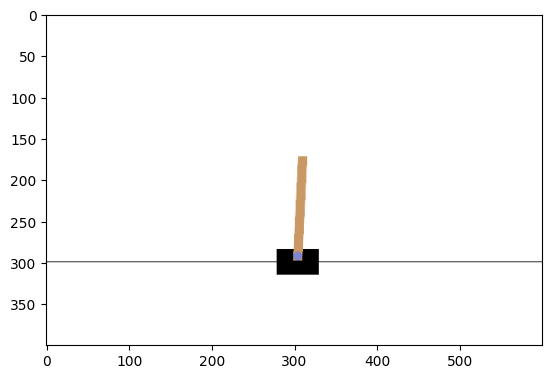

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# if you see "<classname> has no attribute .env", remove .env or update gym
env = gym.make("CartPole-v0", render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)

env.close()

# Neural Network Policy

For this assignment we'll utilize the simplified neural network implementation from __[Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)__. Here's what you'll need:

* `agent.partial_fit(states, actions)` - make a single training pass over the data. Maximize the probability of :actions: from :states:
* `agent.predict_proba(states)` - predict probabilities of all actions, a matrix of shape __[len(states), n_actions]__


In [ ]:
from sklearn.neural_network import MLPClassifier

agent = MLPClassifier(
    hidden_layer_sizes=(20, 20),
    activation="tanh",
)

# initialize agent to the dimension of state space and number of actions
agent.partial_fit([env.reset()[0]] * n_actions, range(n_actions), classes=range(n_actions))

In [ ]:
def generate_session(env, agent, t_max=1000):
    """
    Play a single game using agent neural network.
    Terminate when game finishes or after :t_max: steps
    """
    states, actions = [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):

        # use agent to predict a vector of action probabilities for state :s:
        probs = agent.predict_proba([s]).reshape(-1)

        assert probs.shape == (n_actions,), "make sure probabilities are a vector (hint: np.reshape)"

        # use the probabilities you predicted to pick an action
        # sample proportionally to the probabilities, don't just take the most likely action
        a = np.random.choice(n_actions, p=probs)
        # ^-- hint: try np.random.choice

        new_s, r, terminated, truncated, _ = env.step(a)

        # record sessions like you did before
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward


In [ ]:
dummy_states, dummy_actions, dummy_reward = generate_session(env, agent, t_max=5)
print("states:", np.stack(dummy_states))
print("actions:", dummy_actions)
print("reward:", dummy_reward)


states: [[ 0.04670766 -0.03415019 -0.02907851  0.03082634]
 [ 0.04602465 -0.22884333 -0.02846199  0.3141947 ]
 [ 0.04144779 -0.03332774 -0.02217809  0.01267341]
 [ 0.04078123 -0.22812472 -0.02192462  0.2982772 ]
 [ 0.03621874 -0.4229274  -0.01595908  0.58396566]]
actions: [0, 1, 0, 0, 0]
reward: 5.0


### CEM steps
Deep CEM uses exactly the same strategy as the regular CEM, so you can copy your function code from previous notebook.

The only difference is that now each observation is not a number but a `float32` vector.

In [ ]:
import pandas as pd

def round_state(state):
    state[0] = state[0].round(2)
    state[1] = state[1].round(1)
    state[2] = state[2].round(2)
    state[3] = state[3].round(1)
    return state


def select_elites(states_batch, actions_batch, rewards_batch, percentile=50, sample_frac=0.2):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """
    quantile = percentile / 100

    sar = []
    for i in range(len(states_batch)):
        for s, a in zip(states_batch[i], actions_batch[i]):
            r = rewards_batch[i]
            sar.append((s, a, r))

    sar = pd.DataFrame(sar, columns=['state', 'action', 'reward'])

    sar["state_key"] = sar["state"].apply(lambda x: tuple(round_state(x)))
    sar["state_reward_threshold"] = sar.groupby("state_key")["reward"].transform(lambda s: s.quantile(quantile))

    duplicate = sar["state_key"].duplicated(keep=False)
    sample_idx = sar.index[~duplicate].to_series().sample(frac=sample_frac, replace=False).index

    sample_condition = sar.index.isin(sample_idx)
    elite_condition = (duplicate & (sar["reward"] >= sar["state_reward_threshold"]))
    elite_sar = sar[elite_condition | sample_condition]

    print(f"Selected {len(elite_sar)} elite states from {len(sar)} states.")
    print(f"Mean number of duplicate states: {sar['state_key'].value_counts().mean().round(2)}")
    print(f"Mean number of duplicate elite states: {elite_sar['state_key'].value_counts().mean().round(2)}")

    elite_states, elite_actions = elite_sar["state"].tolist(), elite_sar["action"].tolist()
    return elite_states, elite_actions


# Training loop
Generate sessions, select N best and fit to those.

In [ ]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    plt.show()


Selected 109566 elite states from 328684 states.
Mean number of duplicate states: 2.72
Mean number of duplicate elite states: 1.77
mean reward = 328.684, threshold=364.900


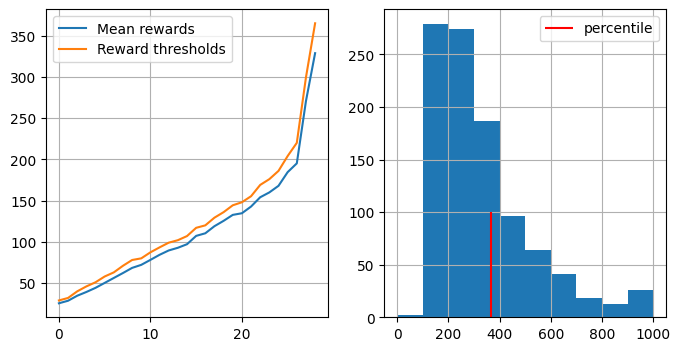

You Win! You may stop training now via KeyboardInterrupt.


In [ ]:
n_sessions = 1000
percentile = 70
log = []

for i in range(100):
    clear_output(True)
    # generate new sessions
    sessions = [generate_session(env, agent) for _ in range(n_sessions)]

    states_batch, actions_batch, rewards_batch = zip(*sessions)

    states_history, actions_history = select_elites(
        states_batch,
        actions_batch,
        rewards_batch,
        percentile
    )

    agent.partial_fit(states_history, actions_history)

    show_progress(
        rewards_batch, log, percentile, reward_range=[0, np.max(rewards_batch)]
    )

    if np.mean(rewards_batch) > 190:
        print("You Win! You may stop training now via KeyboardInterrupt.")

    if np.mean(rewards_batch) > 300:
        break


# Results

In [ ]:
# Record sessions

from gymnasium.wrappers import RecordVideo

with RecordVideo(
    env=gym.make("CartPole-v0", render_mode="rgb_array"),
    video_folder="./videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent) for _ in range(3)]


/Users/vbalab/all/venvs/torch_3_14/lib/python3.14/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


In [ ]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path("videos").iterdir() if s.suffix == ".mp4"])
video_path = video_paths[-1]  # You can also try other indices

if "google.colab" in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open("rb") as fp:
        mp4 = fp.read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)


# Homework part I

### Tabular crossentropy method

You may have noticed that the taxi problem quickly converges from -100 to a near-optimal score and then descends back into -50/-100. This is in part because the environment has some innate randomness. Namely, the starting points of passenger/driver change from episode to episode.

### Tasks
- __1.1__ (2 pts) Find out how the algorithm performance changes if you use a different `percentile` and/or `n_sessions`. Provide here some figures so we can see how the hyperparameters influence the performance.
- __1.2__ (1 pts) Tune the algorithm to end up with positive average score.

It's okay to modify the existing code.


# 1.1

In [ ]:
import sys, os
import numpy as np
import pandas as pd
import gymnasium as gym
from pickle import dump
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from dataclasses import dataclass
from IPython.display import clear_output


(314, {'prob': 1.0, 'action_mask': array([1, 1, 0, 0, 0, 0], dtype=int8)})
n_states=500, n_actions=6


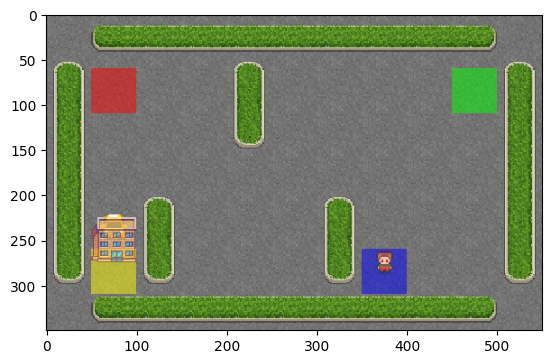

In [ ]:
env = gym.make("Taxi-v3", render_mode="rgb_array")

n_states = env.observation_space.n
n_actions = env.action_space.n

print(env.reset(seed=0))
print(f"n_states={n_states}, n_actions={n_actions}")
plt.imshow(env.render())


In [ ]:
def initialize_policy(n_states, n_actions):
    policy = np.ones([n_states, n_actions]) / n_actions

    return policy


def generate_session(env, policy, t_max=10**4, video=False):
    states, actions = [], []
    total_reward = 0.0

    s, _ = env.reset()

    for t in range(t_max):
        # Hint: you can use np.random.choice for sampling action
        # https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html

        a = np.random.choice(n_actions, p=policy[s])

        new_s, r, terminated, truncated, _ = env.step(a)

        # Record information we just got from the environment.
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        
        if video:
            clear_output()
            plt.imshow(env.render())
            plt.pause(0.1)

        if terminated or truncated:
            break

    return states, actions, total_reward


def select_elites(states_batch, actions_batch, rewards_batch, percentile):
    reward_threshold = np.percentile(rewards_batch, percentile)

    elite_states = []
    elite_actions = []
    for i in range(len(rewards_batch)):
        if rewards_batch[i] >= reward_threshold:
            elite_states.extend(states_batch[i])
            elite_actions.extend(actions_batch[i])

    return elite_states, elite_actions


def get_new_policy(elite_states, elite_actions):
    new_policy = np.zeros([n_states, n_actions])

    for s, a in zip(elite_states, elite_actions):
        try:
            new_policy[s, a] += 1
        except Exception as e:
            print(s)
            print(type(s))
            print(a)
            print(type(a))
            raise e
    new_policy[np.sum(new_policy, axis=1) == 0] = 1
    new_policy /= np.sum(new_policy, axis=1, keepdims=True)
    return new_policy


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()
    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.show()

def train(
    env,
    policy,
    n_sessions = 250,       # sample this many sessions
    percentile = 50,        # discard this percentage of sessions with lowest rewards
    learning_rate = 0.5,    # how quickly the policy is updated, on a scale from 0 to 1
    show = True,
    select_elites_func = select_elites,
    ):
    log = []

    for i in range(100):
        sessions = [generate_session(env, policy) for _ in range(n_sessions)]

        states_batch, actions_batch, rewards_batch = zip(*sessions)

        elite_states, elite_actions = select_elites_func(states_batch, actions_batch, rewards_batch, percentile)

        new_policy = get_new_policy(elite_states, elite_actions)

        policy = learning_rate * new_policy + (1 - learning_rate) * policy

        # display results on chart
        if show:
            show_progress(rewards_batch, log, percentile)

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)

    return policy, mean_reward.item(), threshold


### Changing `percentile`

mean reward = -686.632, threshold=-6.700


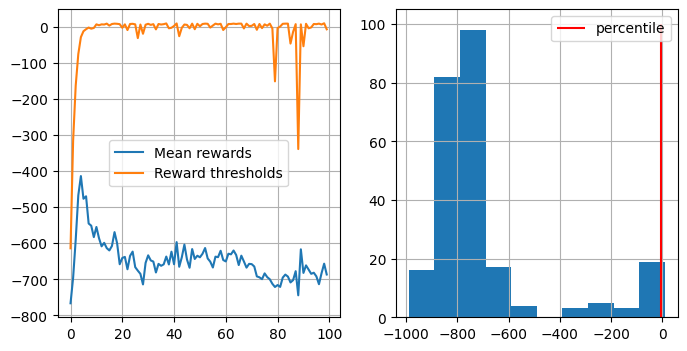

In [ ]:
@dataclass
class ExperimentResult:
    percentile: float
    mean_reward: float
    threshold: float


percentiles = [40, 50, 60, 70, 80, 90, 95]
experiment_results: list[list[ExperimentResult]] = []

n_times = 5

for percentile in tqdm(percentiles):
    policy = initialize_policy(n_states, n_actions)
    
    results = []
    for _ in range(n_times):
        result = train(env, policy, percentile=percentile)
        result = ExperimentResult(percentile, result[1], result[2])
        results.append(result)

    experiment_results.append(results)


with open("experiment_results.pkl", 'wb') as f:
    dump(experiment_results, f)


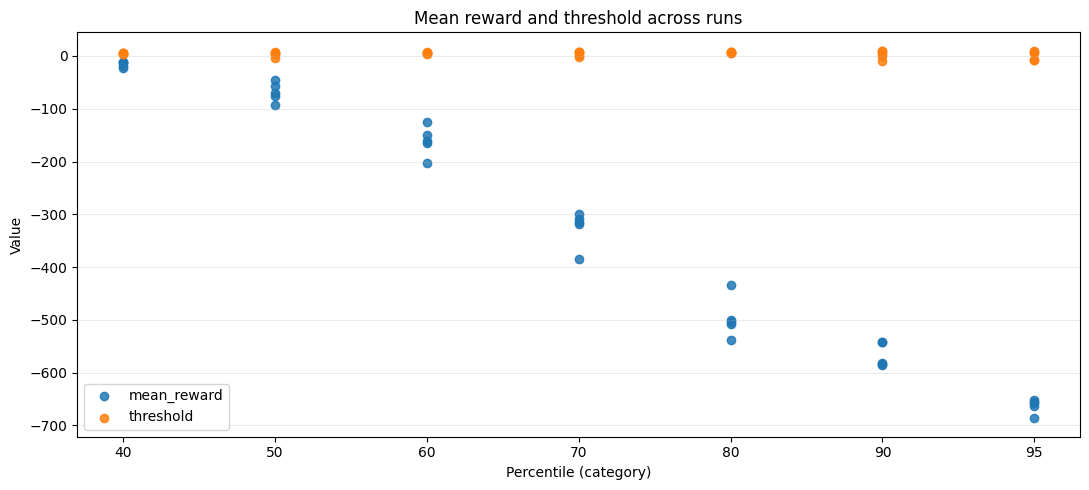

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- flatten experiment_results -> DataFrame ---
rows = []
for group in experiment_results:
    for r in group:
        rows.append(
            {
                "percentile": int(r.percentile),
                "mean_reward": float(r.mean_reward),
                "threshold": float(r.threshold),
            }
        )
df = pd.DataFrame(rows)

# treat percentiles as categorical (even spacing)
cats = [str(p) for p in sorted(df["percentile"].unique())]
x_map = {int(p): i for i, p in enumerate(cats, start=1)}

df["x"] = df["percentile"].map(x_map)

fig, ax = plt.subplots(figsize=(11, 5))

ax.scatter(df["x"], df["mean_reward"], label="mean_reward", alpha=0.85)
ax.scatter(df["x"], df["threshold"],  label="threshold",  alpha=0.85)

ax.set_xticks(range(1, len(cats) + 1))
ax.set_xticklabels(cats)
ax.set_xlabel("Percentile (category)")
ax.set_ylabel("Value")
ax.set_title("Mean reward and threshold across runs")

ax.grid(True, axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

### Changing `n_sessions`

mean reward = -88.877, threshold=8.000


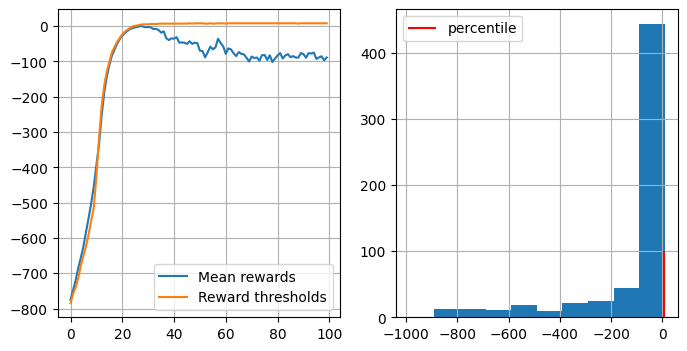

In [ ]:
@dataclass
class ExperimentResult:
    n_sessions: float
    mean_reward: float
    threshold: float


n_sessionss = [100, 200, 300, 500, 700]
experiment_results: list[list[ExperimentResult]] = []

n_times = 5

for n_sessions in tqdm(n_sessionss):
    policy = initialize_policy(n_states, n_actions)
    
    results = []
    for _ in range(n_times):
        result = train(env, policy, n_sessions=n_sessions)
        result = ExperimentResult(n_sessions, result[1], result[2])
        results.append(result)

    experiment_results.append(results)


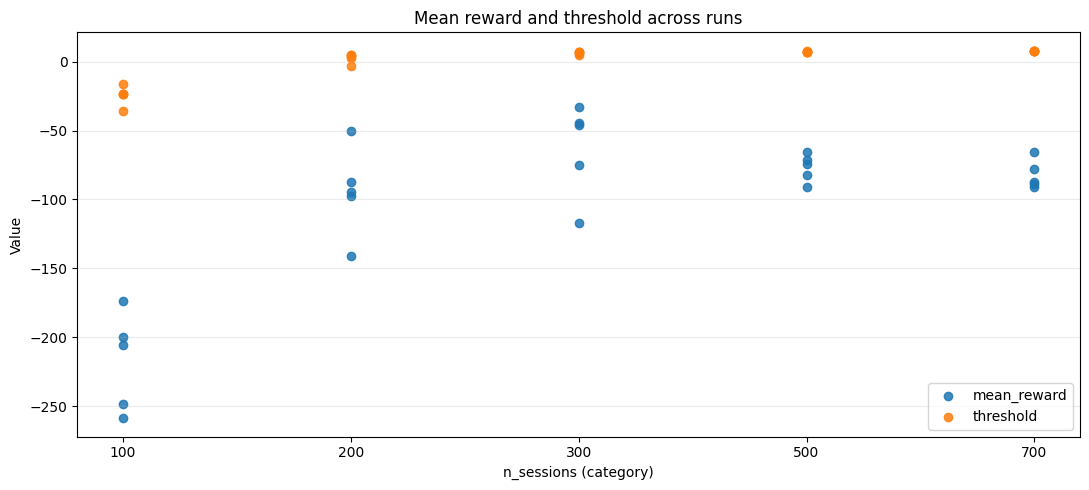

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- flatten experiment_results -> DataFrame ---
rows = []
for group in experiment_results:
    for r in group:
        rows.append(
            {
                "n_sessions": int(r.n_sessions),
                "mean_reward": float(r.mean_reward),
                "threshold": float(r.threshold),
            }
        )
df = pd.DataFrame(rows)

# treat n_sessions as categorical (even spacing)
cats = [str(p) for p in sorted(df["n_sessions"].unique())]
x_map = {int(p): i for i, p in enumerate(cats, start=1)}

df["x"] = df["n_sessions"].map(x_map)

fig, ax = plt.subplots(figsize=(11, 5))

ax.scatter(df["x"], df["mean_reward"], label="mean_reward", alpha=0.85)
ax.scatter(df["x"], df["threshold"],  label="threshold",  alpha=0.85)

ax.set_xticks(range(1, len(cats) + 1))
ax.set_xticklabels(cats)
ax.set_xlabel("n_sessions (category)")
ax.set_ylabel("Value")
ax.set_title("Mean reward and threshold across runs")

ax.grid(True, axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# 1.2

In [ ]:
def select_elites_per_state(states_batch, actions_batch, rewards_batch, percentile):
    sar = []
    for i in range(len(states_batch)):
        for s, a in zip(states_batch[i], actions_batch[i]):
            r = rewards_batch[i]
            sar.append((s, a, r))

    quantile = percentile / 100
    sar = pd.DataFrame(sar, columns=['state', 'action', 'reward'])
    sar["state_reward_threshold"] = sar.groupby("state")["reward"].transform(lambda s: s.quantile(quantile))
    sar = sar[sar["reward"] > sar["state_reward_threshold"]]

    elite_states, elite_actions = sar["state"].tolist(), sar["action"].tolist()
    return elite_states, elite_actions


mean reward = 2.752, threshold=6.000


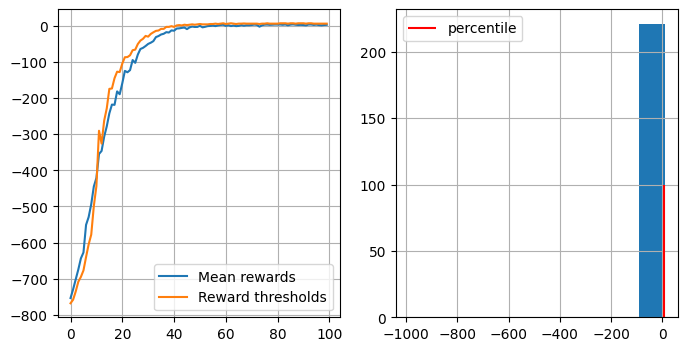

In [ ]:
policy = initialize_policy(n_states, n_actions)    

result = train(
    env,
    policy,
    select_elites_func=select_elites_per_state,
)

policy = result[0]

with open("taxi_agent.pkl", 'wb') as f:
    dump(policy, f)


> ЧТО ЖЕ Я СДЕЛАЛ: переписал `select_elites` на версию, которая всегда учитывает все состояния, которые имеются, а не только те, которые лучше в целом

# Homework part II

### Deep crossentropy method

By this moment, you should have got enough score on [CartPole-v0](https://gymnasium.farama.org/environments/classic_control/cart_pole/) to consider it solved (see the link). It's time to try something harder.

* if you have any trouble with CartPole-v0 and feel stuck, feel free to ask us or your peers for help.

### Tasks

* __2.1__ (3 pts) Pick one of environments: `MountainCar-v0` or `LunarLander-v2`.
  * For MountainCar, get average reward of __at least -150__
  * For LunarLander, get average reward of __at least +50__

See the tips section below, it's kinda important.
__Note:__ If your agent is below the target score, you'll still get some of the points depending on the result, so don't be afraid to submit it.
  
  
* __2.2__ (up to 6 pts) Devise a way to speed up training against the default version
  * Obvious improvement: use [`joblib`](https://joblib.readthedocs.io/en/latest/). However, note that you will probably need to spawn a new environment in each of the workers instead of passing it via pickling. (2 pts)
  * Try re-using samples from 3-5 last iterations when computing threshold and training. (2 pts)
  * Obtain __-100__ at `MountainCar-v0` or __+200__ at `LunarLander-v2` (2 pts). Feel free to experiment with hyperparameters, architectures, schedules etc.
  
__Please list what you did in Anytask submission form__. This reduces probability that somebody misses something.
  
  
### Tips
* Gymnasium pages: [MountainCar](https://gymnasium.farama.org/environments/classic_control/mountain_car/), [LunarLander](https://gymnasium.farama.org/environments/box2d/lunar_lander/)
* Sessions for MountainCar may last for 10k+ ticks. Make sure ```t_max``` param is at least 10k.
 * Also it may be a good idea to cut rewards via ">" and not ">=". If 90% of your sessions get reward of -10k and 10% are better, than if you use percentile 20% as threshold, R >= threshold __fails to cut off bad sessions__ while R > threshold works alright.
* _issue with gym_: Some versions of gym limit game time by 200 ticks. This will prevent cem training in most cases. Make sure your agent is able to play for the specified __t_max__, and if it isn't, try `env = gym.make("MountainCar-v0").env` or otherwise get rid of TimeLimit wrapper.
* If you use old _swig_ lib for LunarLander-v2, you may get an error. See this [issue](https://github.com/openai/gym/issues/100) for solution.
* If it doesn't train, it's a good idea to plot reward distribution and record sessions: they may give you some clue. If they don't, call course staff :)
* 20-neuron network is probably not enough, feel free to experiment.

You may find the following snippet useful:

# 2.1

In [ ]:
import sys
import numpy as np
import gymnasium as gym
from pickle import dump
import matplotlib.pyplot as plt
from IPython.display import clear_output
from gymnasium.wrappers import RecordVideo
from sklearn.neural_network import MLPClassifier



(array([ 0.00570612,  1.3990337 ,  0.5779654 , -0.5282996 , -0.0066053 ,
       -0.13091767,  0.        ,  0.        ], dtype=float32), {})
state_dim=8, n_actions=4


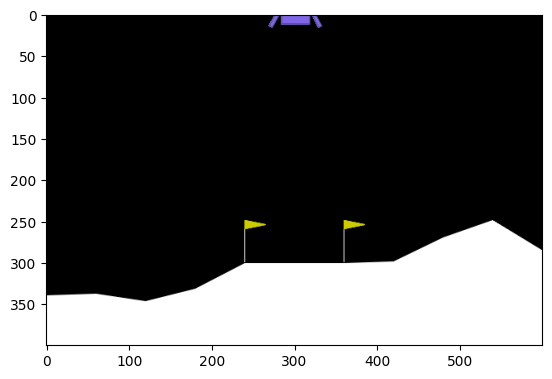

In [ ]:
env = gym.make("LunarLander-v3", render_mode="rgb_array")

state_dim = env.observation_space.shape[0]
n_actions = env.action_space.n

print(env.reset(seed=0))
print(f"state_dim={state_dim}, n_actions={n_actions}")
plt.imshow(env.render())


In [ ]:
agent = MLPClassifier(
    hidden_layer_sizes=(128, 128, 128),
    activation="relu",
)

# initialize agent to the dimension of state space and number of actions
obs, _ = env.reset()

agent.partial_fit(
    [obs] * n_actions,
    np.arange(n_actions),
    classes=np.arange(n_actions),
)


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


In [ ]:
def generate_session(env, agent, t_max=1000, gamma=0.995, eps = 0.05):
    states, actions, rewards = [], [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):
        probs = agent.predict_proba([s]).reshape(-1)

        if eps and eps > 0.0:
            probs = (1 - eps) * probs + eps / n_actions
        assert probs.shape == (n_actions,), "make sure probabilities are a vector (hint: np.reshape)"

        a = np.random.choice(n_actions, p=probs)

        new_s, r, terminated, truncated, _ = env.step(a)

        states.append(s)
        actions.append(a)

        rewards.append(r)
        total_reward += r
        
        s = new_s
        if terminated or truncated:
            break

    # G = 0
    # for t in reversed(range(len(rewards))):
    #     G = rewards[t] + gamma * G
    #     rewards[t] = G

    return states, actions, rewards, total_reward


In [ ]:
def select_elites(states_batch, actions_batch, total_rewards, percentile=70):
    thr = np.percentile(total_rewards, percentile)
    elite_states, elite_actions = [], []
    
    states_num = 0
    for states, actions, R in zip(states_batch, actions_batch, total_rewards):
        states_num += len(states)
        if R > thr:
            elite_states.extend(states)
            elite_actions.extend(actions)

    print(f"Selected {len(elite_states)} elites from {states_num} states.")
    return elite_states, elite_actions

In [ ]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    plt.show()


Selected 119144 elites from 252084 states.
mean reward = 50.006, threshold=84.338


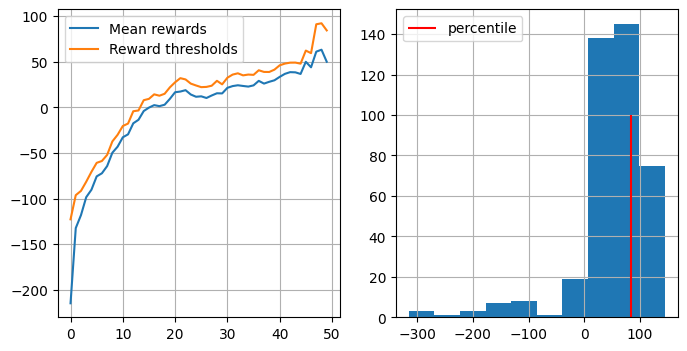

You Win! You may stop training now via KeyboardInterrupt.


In [ ]:
env = gym.make("LunarLander-v3")    # no render_mode while training

n_sessions = 400
percentile = 70
log = []

for i in range(100):
    # generate new sessions
    sessions = []
    for _ in range(n_sessions):
        sessions.append(generate_session(env, agent))

    clear_output(True)

    states_batch, actions_batch, rewards_batch, total_reward = zip(*sessions)

    states_history, actions_history = select_elites(
        states_batch,
        actions_batch,
        total_reward,
        percentile,

    )

    for _ in range(3):
        agent.partial_fit(states_history, actions_history)

    show_progress(
        total_reward, log, percentile, reward_range=[np.min(total_reward) - 1, np.max(total_reward) + 1]
    )

    if np.mean(total_reward) > 50:
        with open("lunar_lander_agent.pkl", 'wb') as f:
            dump(agent, f)
        print("You Win! You may stop training now via KeyboardInterrupt.")
        break

    with RecordVideo(
        env=gym.make("LunarLander-v3", render_mode="rgb_array"),
        video_folder="./videos",
        episode_trigger=lambda episode_number: True,
    ) as env_monitor:
        sessions = [generate_session(env_monitor, agent) for _ in range(3)]


# 2.2

In [ ]:
import numpy as np
import gymnasium as gym
from joblib import Parallel, delayed


def run_one_session(
    agent,
    seed,
    env_name = "LunarLander-v3",
    t_max=1000,
    gamma=0.995,
    eps=0.05,
):
    env = gym.make(env_name)  # no render_mode in parallel
    env.reset(seed=seed)
    return generate_session(env, agent, t_max=t_max, gamma=gamma, eps=eps)


In [ ]:
elite_states_history = []
elite_actions_history = []
elite_rewards_history = []

def extend_sar_history(elite_states, elite_actions, elite_rewards, n_history_batches=10):
    global elite_states_history, elite_actions_history, elite_rewards_history

    elite_states_history.extend(elite_states)
    elite_actions_history.extend(elite_actions)
    elite_rewards_history.extend(elite_rewards)

    extra = len(elite_states_history) - n_history_batches * len(elite_states)
    if extra > 0:
        elite_states_history = elite_states_history[extra:]
        elite_actions_history = elite_actions_history[extra:]
        elite_rewards_history = elite_rewards_history[extra:]


def select_elites(states_batch, actions_batch, total_rewards, percentile=70):
    thr = np.percentile(total_rewards, percentile)
    elite_states, elite_actions, elite_rewards = [], [], []
    
    states_num = 0
    for states, actions, r in zip(states_batch, actions_batch, total_rewards):
        n_states = len(states)
        states_num += n_states
        if r > thr:
            elite_states.extend(states)
            elite_actions.extend(actions)
            elite_rewards.extend([r] * n_states)

    print(f"Selected {len(elite_states)} elites from {states_num} states.")
    return elite_states, elite_actions, elite_rewards


def select_elites_history(percentile=70):
    global elite_states_history, elite_actions_history, elite_rewards_history

    thr = np.percentile(elite_rewards_history, percentile)
    elite_states, elite_actions, elite_rewards = [], [], []

    for states, actions, r in zip(elite_states_history, elite_actions_history, elite_rewards_history):
        if r > thr:
            elite_states.append(states)
            elite_actions.append(actions)
            elite_rewards.append(r)

    print(f"Selected {len(elite_states)} history elites from {len(elite_states_history)} history states.")
    return elite_states, elite_actions, elite_rewards


def select_elites_from_last_n_batches(
    states_batch,
    actions_batch,
    total_reward,
    percentile,
    elite_percentile,
):
    elite_states, elite_actions, elite_rewards = select_elites(
        states_batch,
        actions_batch,
        total_reward,
        percentile,
    )

    extend_sar_history(elite_states, elite_actions, elite_rewards)

    return select_elites_history(elite_percentile)


Selected 61427 elites from 511242 states.
Selected 91771 history elites from 614270 history states.
mean reward = 202.774, threshold=281.708


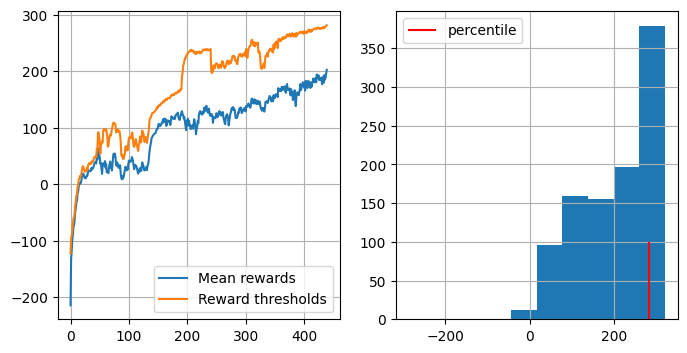

You Win! You may stop training now via KeyboardInterrupt.


In [ ]:
base_seed = 12345

n_history_batches = 10
n_sessions = 1000
percentile = 80
elite_percentile = 85
# log = []

for i in range(100):
    # generate new sessions
    sessions = Parallel(n_jobs=10, backend="loky", prefer="processes")(
        delayed(run_one_session)(
            agent,
            seed=base_seed + i,
            t_max=1000,
            gamma=0.995,
            eps=0.0,
            # eps=0.01,
        )
        for i in range(n_sessions)
    )

    clear_output(True)

    states_batch, actions_batch, _, total_reward = zip(*sessions)

    states_history, actions_history, rewards_history = select_elites_from_last_n_batches(
        states_batch,
        actions_batch,
        total_reward,
        percentile,
        elite_percentile,
    )

    for _ in range(3):
        agent.partial_fit(states_history, actions_history)

    show_progress(
        total_reward, log, percentile, reward_range=[np.min(total_reward) - 1, np.max(total_reward) + 1]
    )

    if np.mean(total_reward) > 200:
        with open("lunar_lander_agent_2_2.pkl", 'wb') as f:
            dump(agent, f)
        print("You Win! You may stop training now via KeyboardInterrupt.")
        break

    with RecordVideo(
        env=gym.make("LunarLander-v3", render_mode="rgb_array"),
        video_folder="./videos",
        episode_trigger=lambda episode_number: True,
    ) as env_monitor:
        sessions = [generate_session(env_monitor, agent) for _ in range(3)]


In [ ]:
from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

with RecordVideo(
    env=gym.make("LunarLander-v3", render_mode="rgb_array"),
    video_folder="./videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent) for _ in range(3)]

video_path = Path("videos/LunarLander-v3_2_2.mp4")

if "google.colab" in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open("rb") as fp:
        mp4 = fp.read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)


/Users/vbalab/all/venvs/venv_3_12/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/vbalab/all/study/ysda/courses/rl/Practical_RL/week01_intro/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


### Bonus tasks

* __2.3 bonus__ (2 pts) Try to find a network architecture and training params that solve __both__ environments above (_Points depend on implementation. If you attempted this task, please mention it in Anytask submission._)

* __2.4 bonus__ (4 pts) Solve continuous action space task with `MLPRegressor` or similar.
  * Since your agent only predicts the "expected" action, you will have to add noise to ensure exploration.
  * Choose one of [MountainCarContinuous-v0](https://gymnasium.farama.org/environments/classic_control/mountain_car_continuous/) (90+ pts to solve), [LunarLanderContinuous-v2](https://gymnasium.farama.org/environments/box2d/lunar_lander/) (`env = gym.make("LunarLander-v2", continuous=True)`)(200+ pts to solve)
  * 4 points for solving. Slightly less for getting some results below solution threshold. Note that discrete and continuous environments may have slightly different rules, aside from action spaces.

# 2.3

In [ ]:
import sys
import numpy as np
import pandas as pd
import gymnasium as gym
import matplotlib.pyplot as plt
from pickle import dump
from pathlib import Path
from base64 import b64encode
from IPython.display import HTML
from joblib import Parallel, delayed
from IPython.display import clear_output
from gymnasium.wrappers import RecordVideo
from sklearn.neural_network import MLPClassifier


In [ ]:
ENVS = ["MountainCar-v0", "LunarLander-v3"]

In [ ]:
def initialize_agent(env_name):
    if env_name not in ENVS:
        raise ValueError("A")

    env = gym.make(env_name)
    n_actions = env.action_space.n

    agent = MLPClassifier(
        hidden_layer_sizes=(128, 256, 128),
        activation="relu",
        solver="adam",
        learning_rate_init=2e-4,
    )

    obs, _ = env.reset()

    agent.partial_fit(
        [obs] * n_actions,
        np.arange(n_actions),
        classes=np.arange(n_actions),
    )
    return agent

In [ ]:
def generate_session(env, agent, t_max=1000, eps = 0.05):
    states, actions = [], []
    total_reward = 0

    n_actions = env.action_space.n
    s, _ = env.reset()

    for t in range(t_max):
        probs = agent.predict_proba([s]).reshape(-1)

        if eps and eps > 0.0:
            probs = (1 - eps) * probs + eps / n_actions
        assert probs.shape == (n_actions,), "make sure probabilities are a vector (hint: np.reshape)"

        a = np.random.choice(n_actions, p=probs)

        new_s, r, terminated, truncated, _ = env.step(a)

        states.append(s)
        actions.append(a)

        total_reward += r
        
        s = new_s
        if terminated or truncated:
            break

    return states, actions, total_reward


def run_one_session(
    agent,
    seed,
    env_name,
    t_max=1000,
    gamma=0.995,
    eps=0.05,
):
    env = gym.make(
        env_name,
        max_episode_steps=10000 if env_name == "MountainCar-v0" else None,
        )  # no render_mode in parallel
    env.reset(seed=seed)
    return generate_session(env, agent, t_max=t_max, eps=eps)


In [ ]:
def extend_elites_history(elite_states, elite_actions, elite_rewards, n_history_batches=10):
    global elite_states_history, elite_actions_history, elite_rewards_history

    elite_states_history.extend(elite_states)
    elite_actions_history.extend(elite_actions)
    elite_rewards_history.extend(elite_rewards)

    extra = len(elite_states_history) - n_history_batches * len(elite_states)
    if extra > 0:
        elite_states_history = elite_states_history[extra:]
        elite_actions_history = elite_actions_history[extra:]
        elite_rewards_history = elite_rewards_history[extra:]


def select_elites(states_batch, actions_batch, total_rewards, percentile=70):
    thr = np.percentile(total_rewards, percentile)
    elite_states, elite_actions, elite_rewards = [], [], []
    
    states_num = 0
    for states, actions, r in zip(states_batch, actions_batch, total_rewards):
        n_states = len(states)
        states_num += n_states
        if r > thr:
            elite_states.extend(states)
            elite_actions.extend(actions)
            elite_rewards.extend([r] * n_states)

    print(f"Selected {len(elite_states)} elites from {states_num} states.")
    return elite_states, elite_actions, elite_rewards


def select_elites_history(percentile=60):
    global elite_states_history, elite_actions_history, elite_rewards_history

    if len(elite_states_history) == 0:
        return [], []

    thr = np.percentile(elite_rewards_history, percentile)
    elite_states, elite_actions = [], []

    for states, actions, r in zip(elite_states_history, elite_actions_history, elite_rewards_history):
        if r > thr:
            elite_states.append(states)
            elite_actions.append(actions)

    print(f"Selected {len(elite_states)} history elites from {len(elite_states_history)} history states.")
    return elite_states, elite_actions


def select_elites_from_last_n_batches(
    states_batch,
    actions_batch,
    total_reward,
    percentile,
    elite_percentile,
    n_history_batches,
):
    elite_states, elite_actions, elite_rewards = select_elites(
        states_batch,
        actions_batch,
        total_reward,
        percentile,
    )

    extend_elites_history(elite_states, elite_actions, elite_rewards, n_history_batches)

    return select_elites_history(elite_percentile)


In [ ]:
def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    plt.show()


def train_agent(
    agent,
    env_name,
    log: None | list = None,
    n_history_batches = 5,
    n_sessions = 200,
    n_learning_steps = 5,
    percentile = 50,
    elite_percentile = 50,
):
    if env_name not in ENVS:
        raise ValueError("A")

    base_seed = 12345

    log = log if log is not None else []

    GOAL_MEAN_REWARD = 200 if env_name == "LunarLander-v3" else -100
    current_mean_reward = -1e+10

    t_max = 1000 if env_name == "LunarLander-v3" else 5000

    for i in range(1000):
        if env_name == "LunarLander-v3":
            if current_mean_reward > 100:
                eps = 0.0
                n_learning_steps = 1
            elif current_mean_reward > 0:
                eps = 0.01
            else:
                eps = 0.03
        else:
            if current_mean_reward > -150:
                eps = 0.0
                t_max = 200
                n_learning_steps = 1
            elif current_mean_reward > -1000:
                eps = 0.01
                t_max = 1000
            else:
                eps = 0.1

        sessions = Parallel(n_jobs=10, backend="loky", prefer="processes")(
            delayed(run_one_session)(
                agent=agent,
                seed=base_seed + i,
                env_name=env_name,
                t_max=t_max,
                eps=eps,
            )
            for i in range(n_sessions)
        )

        clear_output(True)

        states_batch, actions_batch, total_reward = zip(*sessions)

        elite_states, elite_actions = select_elites_from_last_n_batches(
            states_batch,
            actions_batch,
            total_reward,
            percentile,
            elite_percentile,
            n_history_batches,
        )

        if len(elite_states) > 0:
            for _ in range(n_learning_steps):
                agent.partial_fit(elite_states, elite_actions)

        show_progress(
            total_reward,
            log,
            100 - (100 - percentile) * (100 - elite_percentile) * 0.01, 
            reward_range=[np.min(total_reward) - 1, np.max(total_reward) + 1]
        )

        current_mean_reward = np.mean(total_reward)
        if current_mean_reward > GOAL_MEAN_REWARD:
            with open(f"{env_name}_2_3.pkl", 'wb') as f:
                dump(agent, f)
            print("You Win!")
            break

        with RecordVideo(
            env=gym.make(env_name, render_mode="rgb_array"),
            video_folder="./videos",
            episode_trigger=lambda episode_number: True,
        ) as env_monitor:
            sessions = [generate_session(env_monitor, agent) for _ in range(3)]


### MountainCar-v0

In [ ]:
elite_states_history = []
elite_actions_history = []
elite_rewards_history = []

env_name = ENVS[0]
agent = initialize_agent(env_name)
log = []

Selected 16933 elites from 19985 states.
Selected 30889 history elites from 84665 history states.
mean reward = -99.925, threshold=-103.000


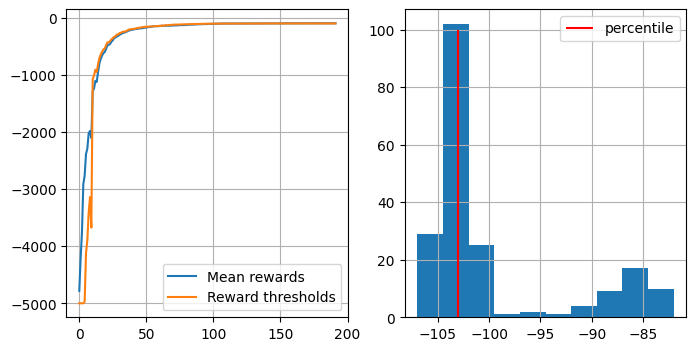

You Win!


In [ ]:
train_agent(agent, env_name, log, percentile=10, elite_percentile=60)

In [ ]:
with RecordVideo(
    env=gym.make(ENVS[0], render_mode="rgb_array"),
    video_folder="./videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent) for _ in range(3)]

video_path = Path(f"videos/MountainCar-v0_2_3.mp4")
data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)


/Users/vbalab/all/venvs/venv_3_12/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/vbalab/all/study/ysda/courses/rl/Practical_RL/week01_intro/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


### LunarLander-v3

In [ ]:
elite_states_history = []
elite_actions_history = []
elite_rewards_history = []

env_name = ENVS[1]
agent = initialize_agent(env_name)
log = []

Selected 104015 elites from 104390 states.
Selected 207158 history elites from 520075 history states.
mean reward = 204.113, threshold=235.597


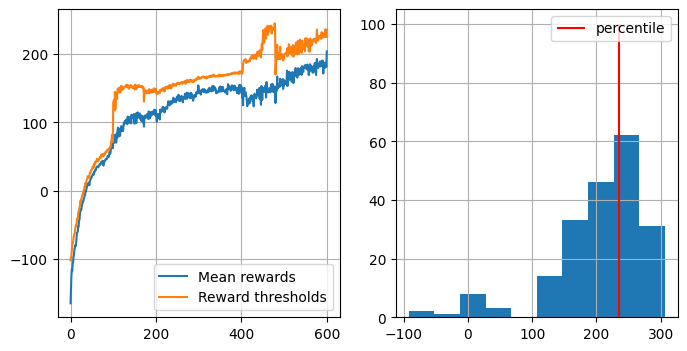

You Win!


In [ ]:
train_agent(agent, env_name, log, percentile=0, elite_percentile=60)

In [ ]:
with RecordVideo(
    env=gym.make(ENVS[1], render_mode="rgb_array"),
    video_folder="./videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent) for _ in range(5)]

video_path = Path(f"videos/LunarLander-v3_2_3.mp4")
data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)


# 2.4

In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from pickle import dump
from pathlib import Path
from base64 import b64encode
from IPython.display import HTML
from joblib import Parallel, delayed
from IPython.display import clear_output
from gymnasium.wrappers import RecordVideo
from sklearn.neural_network import MLPRegressor


In [2]:
ENV_NAME = "MountainCarContinuous-v0"

def initialize_agent(env_name=ENV_NAME):
    env = gym.make(env_name)
    n_actions = env.action_space.shape[0]

    agent = MLPRegressor(
        hidden_layer_sizes=(128, 256, 128),
        activation="relu",
        solver="adam",
        learning_rate_init=2e-4,
    )

    obs, _ = env.reset()

    agent.partial_fit(
        [obs] * n_actions,
        [0],
    )

    return agent

In [3]:
def generate_session(env, agent, t_max=1000, var: None | float = None):
    states, actions = [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):
        a = agent.predict([s])
        
        if var:
            a = np.random.normal(a, var)
        a = np.clip(a, -1, 1)

        new_s, r, terminated, truncated, _ = env.step(a)

        states.append(s)
        actions.append(a)

        total_reward += r
        
        s = new_s
        if terminated or truncated:
            break

    return states, actions, total_reward


def run_one_session(
    agent,
    seed,
    env_name,
    t_max=1000,
    var: None | float = None,
):
    env = gym.make(
        env_name,
        max_episode_steps=50000,
        )  # no render_mode in parallel
    env.reset(seed=seed)
    return generate_session(env, agent, t_max=t_max, var=var)


In [4]:
def extend_elites_history(elite_states, elite_actions, elite_rewards, n_history_batches=10):
    global elite_states_history, elite_actions_history, elite_rewards_history

    elite_states_history.extend(elite_states)
    elite_actions_history.extend(elite_actions)
    elite_rewards_history.extend(elite_rewards)

    extra = len(elite_states_history) - n_history_batches * len(elite_states)
    if extra > 0:
        elite_states_history = elite_states_history[extra:]
        elite_actions_history = elite_actions_history[extra:]
        elite_rewards_history = elite_rewards_history[extra:]


def select_elites(states_batch, actions_batch, total_rewards, percentile=70):
    thr = np.percentile(total_rewards, percentile)
    elite_states, elite_actions, elite_rewards = [], [], []
    
    states_num = 0
    for states, actions, r in zip(states_batch, actions_batch, total_rewards):
        n_states = len(states)
        states_num += n_states
        if r > thr:
            elite_states.extend(states)
            elite_actions.extend(actions)
            elite_rewards.extend([r] * n_states)

    print(f"Selected {len(elite_states)} elites from {states_num} states.")
    return elite_states, elite_actions, elite_rewards


def select_elites_history(percentile=60):
    global elite_states_history, elite_actions_history, elite_rewards_history

    if len(elite_states_history) == 0:
        return [], []

    thr = np.percentile(elite_rewards_history, percentile)
    elite_states, elite_actions = [], []

    for states, actions, r in zip(elite_states_history, elite_actions_history, elite_rewards_history):
        if r > thr:
            elite_states.append(states)
            elite_actions.append(actions)

    print(f"Selected {len(elite_states)} history elites from {len(elite_states_history)} history states.")
    return elite_states, elite_actions


def select_elites_from_last_n_batches(
    states_batch,
    actions_batch,
    total_reward,
    percentile,
    elite_percentile,
    n_history_batches,
):
    elite_states, elite_actions, elite_rewards = select_elites(
        states_batch,
        actions_batch,
        total_reward,
        percentile,
    )

    extend_elites_history(elite_states, elite_actions, elite_rewards, n_history_batches)

    return select_elites_history(elite_percentile)


In [5]:
def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    plt.show()


def train_agent(
    agent,
    env_name,
    log: None | list = None,
    n_history_batches = 5,
    n_sessions = 240,
    n_learning_steps = 5,
    percentile = 50,
    elite_percentile = 50,
):
    assert env_name == "MountainCarContinuous-v0"

    base_seed = 12345

    log = log if log is not None else []

    GOAL_MEAN_REWARD = 90
    wins = 0
    current_mean_reward = -1e+10

    t_max = 3000
    for i in range(1000):
        if current_mean_reward > 90:
            var = 0.0
        if current_mean_reward > 70:
            var = 0.2
            n_learning_steps = 1
        elif current_mean_reward > -200:
            var = 1.0
            t_max = 1000
        else:
            var = 5.0

        sessions = Parallel(n_jobs=10, backend="loky", prefer="processes")(
            delayed(run_one_session)(
                agent=agent,
                seed=base_seed + i,
                env_name=env_name,
                t_max=t_max,
                var=var,
            )
            for i in range(n_sessions)
        )

        clear_output(True)

        states_batch, actions_batch, total_reward = zip(*sessions)

        elite_states, elite_actions = select_elites_from_last_n_batches(
            states_batch,
            actions_batch,
            total_reward,
            percentile,
            elite_percentile,
            n_history_batches,
        )

        if len(elite_states) > 0:
            for _ in range(n_learning_steps):
                agent.partial_fit(elite_states, np.array(elite_actions).ravel())

        show_progress(
            total_reward,
            log,
            100 - (100 - percentile) * (100 - elite_percentile) * 0.01, 
            reward_range=[np.min(total_reward) - 1, np.max(total_reward) + 1]
        )

        current_mean_reward = np.mean(total_reward)
        if current_mean_reward > GOAL_MEAN_REWARD:
            with open(f"{env_name}_2_4.pkl", 'wb') as f:
                dump(agent, f)
            print("You Win!")
            wins += 1
            if wins > 3:
                break
        else:
            wins = 0

        with RecordVideo(
            env=gym.make(env_name, render_mode="rgb_array"),
            video_folder="./videos",
            episode_trigger=lambda episode_number: True,
        ) as env_monitor:
            sessions = [generate_session(env_monitor, agent) for _ in range(3)]


In [6]:
elite_states_history = []
elite_actions_history = []
elite_rewards_history = []

agent = initialize_agent()
log = []

Selected 5951 elites from 84780 states.
Selected 14792 history elites from 29755 history states.
mean reward = 97.311, threshold=97.982


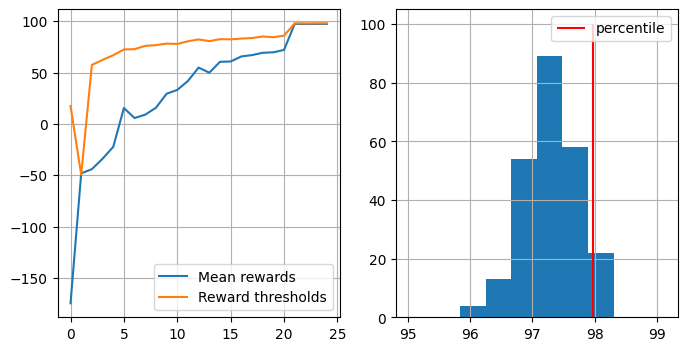

You Win!


In [7]:
train_agent(agent, ENV_NAME, log, percentile=90, elite_percentile=50)

In [ ]:
with RecordVideo(
    env=gym.make(ENV_NAME, render_mode="rgb_array"),
    video_folder="./videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent) for _ in range(5)]

video_path = Path(f"videos/MountainCarContinuous-v0_2_4.mp4")
data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)
